# Scaling sweep: LLM-LA (mine) vs BooM across load levels

**Cross-load presentation view.** Same CodeFlowBench replay driven through the real Claude
Code CLI, `strip_claude_code_attribution` ON everywhere, on **bz** (MiniMax-M2, 2 leader pods).
Four concurrency points on the ramp — **16 → 32 → 64 users** — with all seven methods at
each point:

- **Ours (LLM-LA router, `pull`)**: KV+Len+Aff, Aff (hard), Aff (soft), Prefix
- **BooM (direct)**: Round-Robin, Key-Affinity, KVC-Aware

Experiment map: u16 = 122-125 + 129-131 · u32 = 132-138 · u64 = 139-145.

> **128-user level excluded.** The 128u point (146-152) is left out of this cross-load view: it
> is a saturation regime that doesn't compare cleanly (BooM round-robin pins both pods to hit an
> outlier throughput, and BooM kvc-aware @128u under-generated ~half the tokens/turn). See the
> per-level `u128-mine-vs-boom.ipynb` for that point on its own.

**Metric sourcing.** E2E-mean / RPS / TPS / makespan come from the workload logs (complete at
every level). TTFT-mean and TPOT come from the Prometheus engine backfill; these are **past
retention for the u64 *mine* runs (139-144)**, so those points are omitted from the TTFT/TPOT
panels and, where present, in the overall score. **Overall score** = mean of the normalized
TTFT / TPOT / E2E-mean / RPS / TPS scores (1.0 = the leader at that load level), the same five
metrics as the per-level notebooks; E2E/RPS/TPS use one uniform workload-log definition at every
level. Because the u16/u32 per-level notebooks sourced E2E/TPS from Prometheus instead, their
single-level headline % differ slightly from the values shown here.

## 1. Registry, loaders & metric assembly

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXPERIMENTS_ROOT = Path("/home/saeid/llm-la/src/client/experiments")

# (users, tag) -> {strategy: exp_id}.  Order of strategies fixed below.
LEVELS = [(16, "u16"), (32, "u32"), (64, "u64")]  # 128u excluded (saturation, not comparable)
REGISTRY = {
    16:  {"both+hard": 122, "aff-hard": 123, "aff-soft": 124, "prefix": 125,
          "rr": 129, "key_aff": 130, "kvc": 131},
    32:  {"both+hard": 132, "aff-hard": 133, "aff-soft": 134, "prefix": 135,
          "rr": 136, "key_aff": 137, "kvc": 138},
    64:  {"both+hard": 139, "aff-hard": 140, "aff-soft": 141, "prefix": 142,
          "rr": 143, "key_aff": 144, "kvc": 145},
}
TAG = {u: t for u, t in LEVELS}
USERS = [u for u, _ in LEVELS]

# strategy identity is stable across load levels
MINE_STRATS = ["both+hard", "aff-hard", "aff-soft", "prefix"]
BOOM_STRATS = ["rr", "key_aff", "kvc"]
STRATS = MINE_STRATS + BOOM_STRATS
def is_mine(s): return s in MINE_STRATS

PRETTY = {
    "both+hard": "Ours: KV+Len+Aff", "aff-hard": "Ours: Aff (hard)",
    "aff-soft":  "Ours: Aff (soft)", "prefix":   "Ours: Prefix",
    "rr":        "BooM: Round-Robin", "key_aff": "BooM: Key-Affinity",
    "kvc":       "BooM: KVC-Aware",
}
COLOR = {"both+hard": "#1f4e8c", "aff-hard": "#2b6cb0", "aff-soft": "#4C78A8",
         "prefix": "#7fa8d0", "rr": "#B4413C", "key_aff": "#E45756", "kvc": "#F58518"}
MARKER = {"both+hard": "o", "aff-hard": "s", "aff-soft": "^", "prefix": "D",
          "rr": "v", "key_aff": "P", "kvc": "X"}
def lstyle(s): return "-" if is_mine(s) else "--"
OURS_BLUE, BOOM_RED = "#2b6cb0", "#E45756"

def _read_json(p):
    p = Path(p);  return json.load(p.open()) if p.is_file() else None
def _read_ndjson(p):
    p = Path(p); out = []
    if not p.is_file(): return out
    for ln in p.open("r", encoding="utf-8"):
        ln = ln.strip()
        if ln:
            try: out.append(json.loads(ln))
            except Exception: pass
    return out
def turns_path(e):
    p = EXPERIMENTS_ROOT / str(e) / "claude_client_logs.json"
    return p if p.is_file() else EXPERIMENTS_ROOT / str(e) / "logs.json"

# per-level Prometheus engine backfill (TTFT / TPOT / prefix)
BF = {}
for u, t in LEVELS:
    BF[u] = _read_json(EXPERIMENTS_ROOT / f"prom_engine_backfill_{t}.json") or {}
def bf(u, e, k):
    v = BF[u].get(str(e), {}).get(k)
    return float(v) if v is not None else np.nan

rows = []
for u in USERS:
    for s in STRATS:
        if s not in REGISTRY[u]:      # e.g. kvc@128 intentionally excluded
            continue
        e = REGISTRY[u][s]
        rs = _read_json(EXPERIMENTS_ROOT / str(e) / "run_summary.json") or {}
        load_s = rs.get("load_runner_duration_s")
        df = pd.DataFrame(_read_ndjson(turns_path(e)))
        for c in ("end_to_end_s", "completion_tokens"):
            df[c] = pd.to_numeric(df.get(c), errors="coerce") if c in df else np.nan
        n = len(df)
        comp = df["completion_tokens"].sum() if n else np.nan
        rows.append({
            "users": u, "strategy": s, "side": "mine" if is_mine(s) else "boom",
            "exp": e, "pretty": PRETTY[s],
            "e2e_mean": df["end_to_end_s"].mean() if n else np.nan,
            "makespan_min": (load_s / 60.0) if load_s else np.nan,
            "rps": (n / load_s) if load_s else np.nan,
            "tps": (comp / load_s) if load_s else np.nan,
            "ttft_mean": bf(u, e, "ttft_avg"),
            "tpot": bf(u, e, "tpot_derived_s"),
        })
D = pd.DataFrame(rows)

def cell(u, s, col):
    """Robust lookup: NaN if a (load, method) point is intentionally absent (e.g. kvc@128)."""
    r = D[(D.users == u) & (D.strategy == s)]
    return r[col].iloc[0] if len(r) else np.nan

# ---- overall normalized score per load level (1.0 = leader at that level) ----
# Same 5 metrics as the per-level notebooks (TTFT/TPOT lower-better; RPS/TPS
# higher-better; E2E lower-better). E2E/RPS/TPS use one uniform WORKLOAD-log
# definition at every level; TTFT/TPOT come from the engine backfill and are
# skipped where missing (u64 mine, 139-144, past retention) so a method is scored
# on whatever metrics it has -- exactly as the per-level u64 notebook did.
# NOTE: u16/u32 per-level notebooks sourced E2E/TPS from Prometheus instead of the
# workload logs, so their single-level headline % differ slightly from here.
SCORE_METRICS = [("ttft_mean", False), ("tpot", False), ("e2e_mean", False),
                 ("rps", True), ("tps", True)]
def _level_scores(u):
    sub = D[D["users"] == u]
    per = {s: [] for s in STRATS}
    for col, hb in SCORE_METRICS:
        vals = {r.strategy: getattr(r, col) for r in sub.itertuples() if pd.notna(getattr(r, col))}
        if not vals:
            continue
        m = max(vals.values()) if hb else min(vals.values())
        for s, v in vals.items():
            per[s].append(v / m if hb else m / v)
    return {s: float(np.mean(per[s])) for s in STRATS if per[s]}
SCORES = {u: _level_scores(u) for u in USERS}
D["score"] = [SCORES[r.users].get(r.strategy, np.nan) for r in D.itertuples()]

def pivot(col):
    return D.pivot(index="strategy", columns="users", values=col).reindex(STRATS)

print("=== overall normalized score  (5-metric; rows=method, cols=users) ===")
display(pivot("score").rename(index=PRETTY).round(3))
print("=== E2E latency mean (s) ===")
display(pivot("e2e_mean").rename(index=PRETTY).round(1))
print("=== token throughput TPS (tok/s) ===")
display(pivot("tps").rename(index=PRETTY).round(1))


=== overall normalized score  (5-metric; rows=method, cols=users) ===


users,16,32,64
strategy,,,
Ours: KV+Len+Aff,0.745,0.866,0.765
Ours: Aff (hard),0.699,0.940,0.998
Ours: Aff (soft),0.692,0.860,0.866
Ours: Prefix,0.953,0.863,0.705
BooM: Round-Robin,0.591,0.881,0.924
BooM: Key-Affinity,0.594,0.784,0.711
BooM: KVC-Aware,0.536,0.956,0.913


=== E2E latency mean (s) ===


users,16,32,64
strategy,,,
Ours: KV+Len+Aff,169.1,292.8,366.0
Ours: Aff (hard),172.2,324.9,223.7
Ours: Aff (soft),136.5,262.5,248.3
Ours: Prefix,70.7,285.0,325.5
BooM: Round-Robin,165.5,272.1,266.1
BooM: Key-Affinity,208.1,325.2,350.3
BooM: KVC-Aware,226.2,291.2,269.0


=== token throughput TPS (tok/s) ===


users,16,32,64
strategy,,,
Ours: KV+Len+Aff,142.9,128.5,180.0
Ours: Aff (hard),119.3,169.6,179.0
Ours: Aff (soft),102.0,102.2,151.8
Ours: Prefix,118.8,126.8,138.8
BooM: Round-Robin,71.8,126.0,176.0
BooM: Key-Affinity,95.0,108.2,137.4
BooM: KVC-Aware,67.1,171.9,162.1


## 2. How each method scales with load

Small-multiple line panels: one line per method (blue = Ours, warm = BooM), x-axis = concurrent
users. Solid = Ours, dashed = BooM. TTFT/TPOT panels drop the u64-mine points that are past
Prometheus retention.

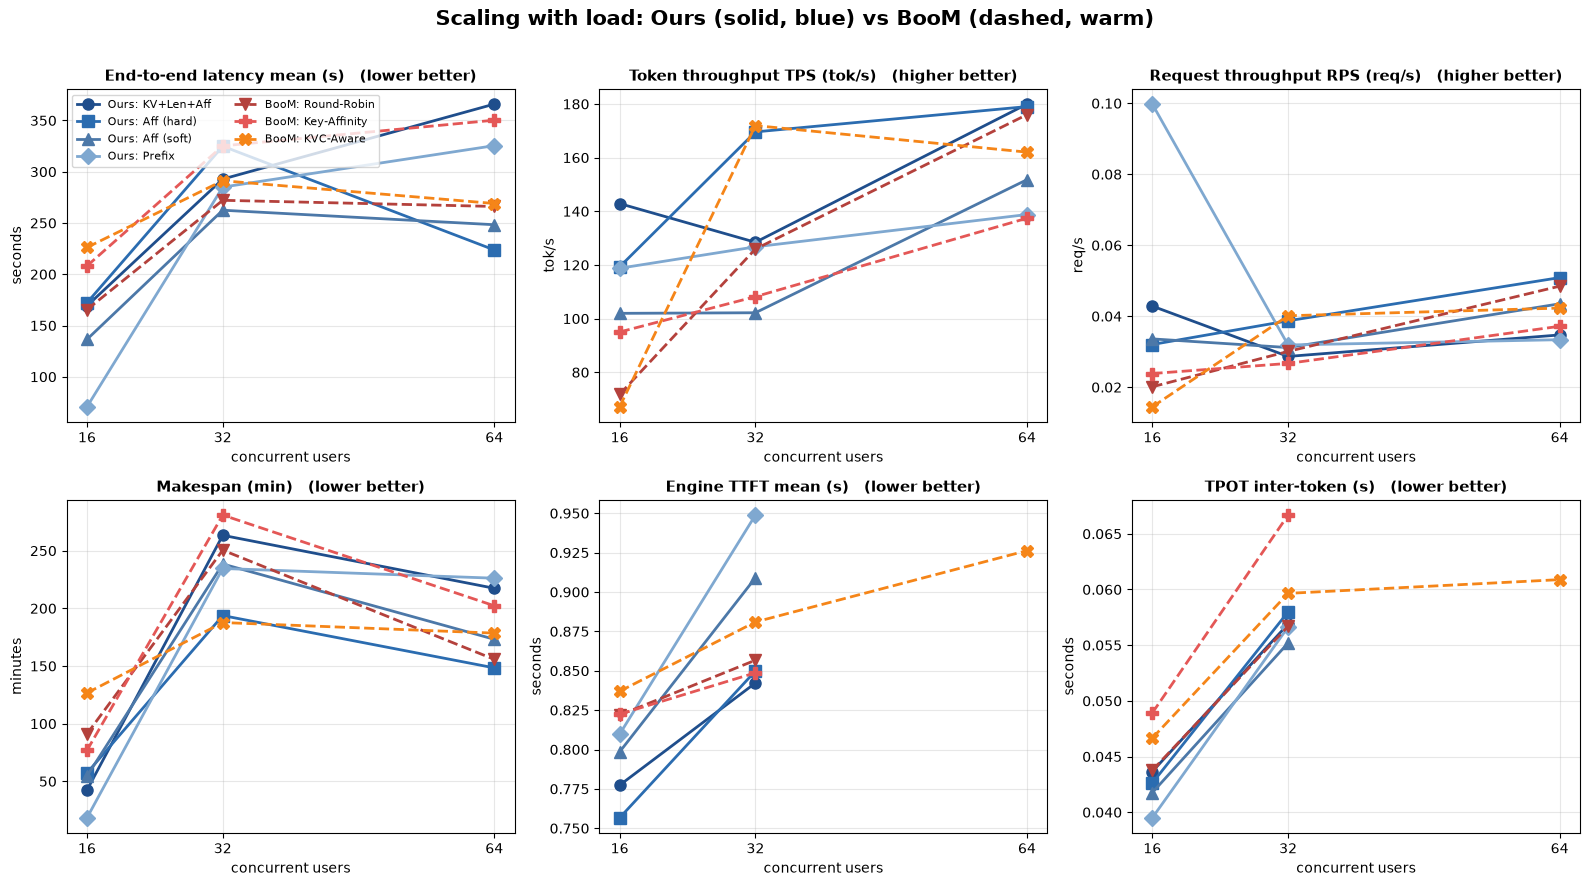

In [2]:
PANELS = [
    ("e2e_mean",     "End-to-end latency mean (s)",   "seconds", False),
    ("tps",          "Token throughput TPS (tok/s)",  "tok/s",   True),
    ("rps",          "Request throughput RPS (req/s)","req/s",   True),
    ("makespan_min", "Makespan (min)",                "minutes", False),
    ("ttft_mean",    "Engine TTFT mean (s)",          "seconds", False),
    ("tpot",         "TPOT inter-token (s)",          "seconds", False),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, title, unit, hb) in zip(axes.ravel(), PANELS):
    for s in STRATS:
        ys = [cell(u, s, col) for u in USERS]
        xs = [u for u, y in zip(USERS, ys) if pd.notna(y)]
        yy = [y for y in ys if pd.notna(y)]
        if not xs:
            continue
        ax.plot(xs, yy, marker=MARKER[s], ls=lstyle(s), color=COLOR[s], lw=2,
                ms=8, label=PRETTY[s])
    ax.set_title(title + ("   (higher better)" if hb else "   (lower better)"),
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("concurrent users"); ax.set_ylabel(unit)
    ax.set_xticks(USERS); ax.grid(alpha=.3)
axes.ravel()[0].legend(fontsize=8, ncol=2, loc="upper left")
fig.suptitle("Scaling with load: Ours (solid, blue) vs BooM (dashed, warm)",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


## 3. Best Ours vs best BooM at each load level

At every load level we take the winning method on each side for the metric and show them side by
side, with the % by which best-Ours beats best-BooM (green = Ours ahead, red = behind).

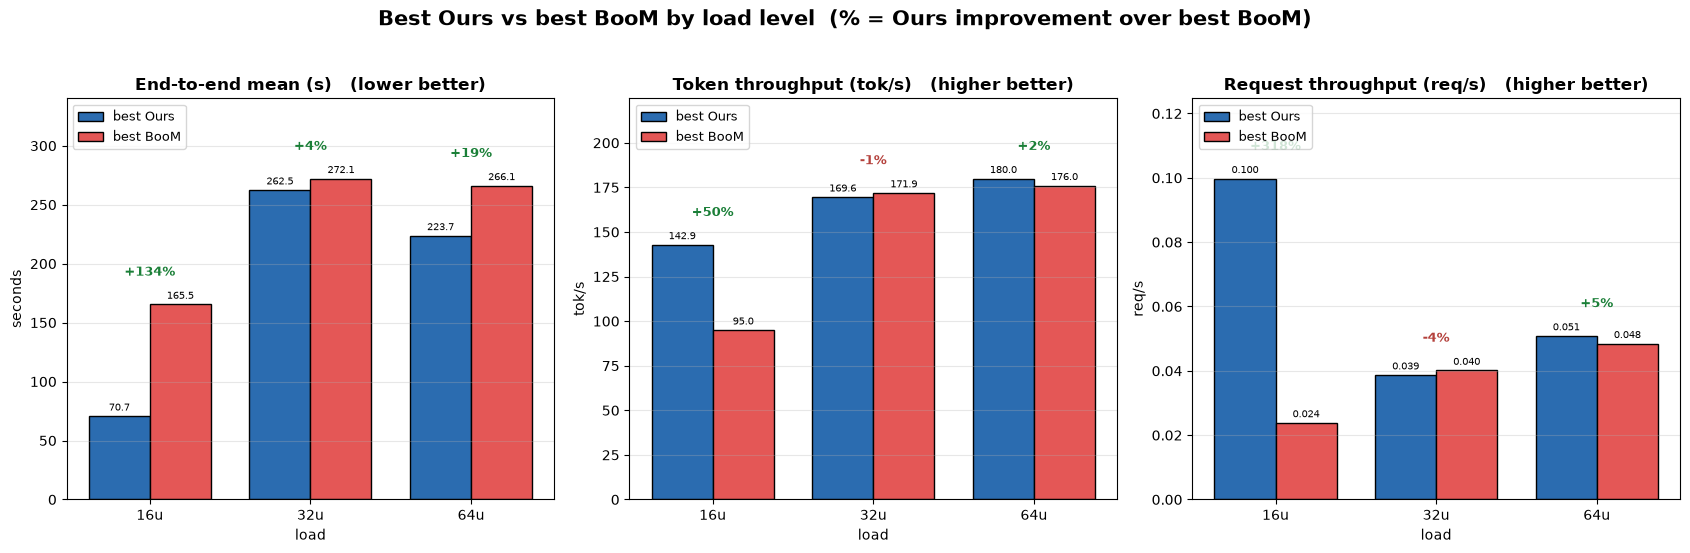

In [3]:
def best_pair(u, col, hb):
    sub = D[(D.users == u) & D[col].notna()]
    if sub.empty:
        return None
    mine = sub[sub.side == "mine"]; boom = sub[sub.side == "boom"]
    if mine.empty or boom.empty:
        return None
    pick = (lambda g: g.loc[g[col].idxmax()]) if hb else (lambda g: g.loc[g[col].idxmin()])
    mo, bo = pick(mine), pick(boom)
    pct = (mo[col] / bo[col] - 1) * 100 if hb else (bo[col] / mo[col] - 1) * 100
    return mo, bo, pct

TRIO = [("e2e_mean", "End-to-end mean (s)", "seconds", False, "{:.1f}"),
        ("tps",      "Token throughput (tok/s)", "tok/s", True, "{:.1f}"),
        ("rps",      "Request throughput (req/s)", "req/s", True, "{:.3f}")]
fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
for ax, (col, title, unit, hb, vf) in zip(axes, TRIO):
    x = np.arange(len(USERS)); w = 0.38
    ours_y, boom_y, pcts = [], [], []
    for u in USERS:
        bp = best_pair(u, col, hb)
        if bp is None:
            ours_y.append(np.nan); boom_y.append(np.nan); pcts.append(np.nan); continue
        mo, bo, pct = bp
        ours_y.append(mo[col]); boom_y.append(bo[col]); pcts.append(pct)
    ax.bar(x - w/2, ours_y, w, color=OURS_BLUE, edgecolor="black", label="best Ours")
    ax.bar(x + w/2, boom_y, w, color=BOOM_RED,  edgecolor="black", label="best BooM")
    ymax = np.nanmax(ours_y + boom_y)
    for i, (oy, by, p) in enumerate(zip(ours_y, boom_y, pcts)):
        if pd.notna(oy): ax.text(i - w/2, oy + ymax*0.01, vf.format(oy), ha="center", va="bottom", fontsize=7)
        if pd.notna(by): ax.text(i + w/2, by + ymax*0.01, vf.format(by), ha="center", va="bottom", fontsize=7)
        if pd.notna(p):
            ax.text(i, max(oy, by) + ymax*0.08, f"{p:+.0f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold",
                    color=("#1a7f37" if p >= 0 else "#b4413c"))
    ax.set_xticks(x); ax.set_xticklabels([f"{u}u" for u in USERS])
    ax.set_title(title + ("   (higher better)" if hb else "   (lower better)"),
                 fontsize=12, fontweight="bold")
    ax.set_ylabel(unit); ax.set_xlabel("load"); ax.grid(axis="y", alpha=.3)
    ax.set_ylim(0, ymax * 1.25)
    ax.legend(fontsize=9, loc="upper left")
fig.suptitle("Best Ours vs best BooM by load level  (% = Ours improvement over best BooM)",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


## 4. Overall win-margin vs load (the story)

Two lines — best-Ours vs best-BooM overall score — across the ramp, with the headline gap at
each point. This is the one-slide takeaway: **Ours leads clearly at low load and stays at/above
BooM as load rises to 64 users**.

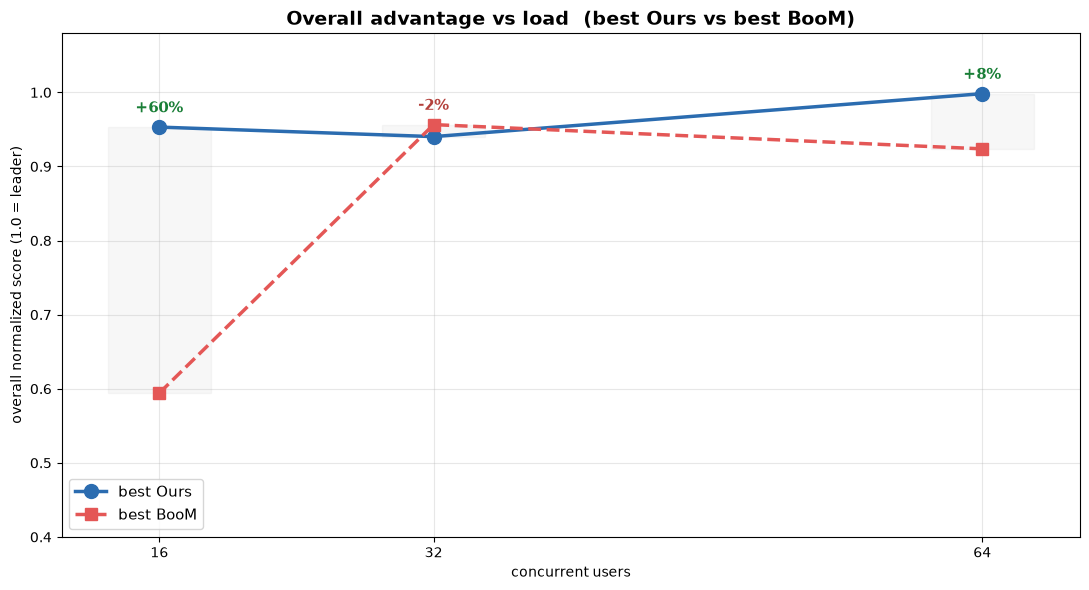

best Ours / best BooM per level:
    16u:  Ours: Prefix         vs BooM: Key-Affinity    ->  +60% overall
    32u:  Ours: Aff (hard)     vs BooM: KVC-Aware       ->  -2% overall
    64u:  Ours: Aff (hard)     vs BooM: Round-Robin     ->  +8% overall


In [4]:
best_ours_s, best_boom_s, gaps = [], [], []
bo_lbl, bb_lbl = [], []
for u in USERS:
    sc = SCORES[u]
    om = max((s for s in sc if is_mine(s)), key=lambda s: sc[s])
    bm = max((s for s in sc if not is_mine(s)), key=lambda s: sc[s])
    best_ours_s.append(sc[om]); best_boom_s.append(sc[bm])
    gaps.append((sc[om] / sc[bm] - 1) * 100)
    bo_lbl.append(PRETTY[om]); bb_lbl.append(PRETTY[bm])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(USERS, best_ours_s, "-o", color=OURS_BLUE, lw=2.5, ms=10, label="best Ours")
ax.plot(USERS, best_boom_s, "--s", color=BOOM_RED, lw=2.5, ms=9, label="best BooM")
for x, yo, yb, g in zip(USERS, best_ours_s, best_boom_s, gaps):
    ax.annotate(f"{g:+.0f}%", ((x), max(yo, yb) + 0.02), ha="center", fontsize=11,
                fontweight="bold", color=("#1a7f37" if g >= 0 else "#b4413c"))
    ax.fill_between([x-3, x+3], min(yo, yb), max(yo, yb), color="gray", alpha=0.06)
ax.set_xticks(USERS); ax.set_ylim(0.4, 1.08)
ax.set_xlabel("concurrent users"); ax.set_ylabel("overall normalized score (1.0 = leader)")
ax.set_title("Overall advantage vs load  (best Ours vs best BooM)",
             fontsize=14, fontweight="bold")
ax.grid(alpha=.3); ax.legend(fontsize=11, loc="lower left")
plt.tight_layout(); plt.show()

print("best Ours / best BooM per level:")
for u, o, b, g in zip(USERS, bo_lbl, bb_lbl, gaps):
    print(f"  {u:>4}u:  {o:20s} vs {b:20s}  ->  {g:+.0f}% overall")


### 4b. Heatmap: every method x every load level

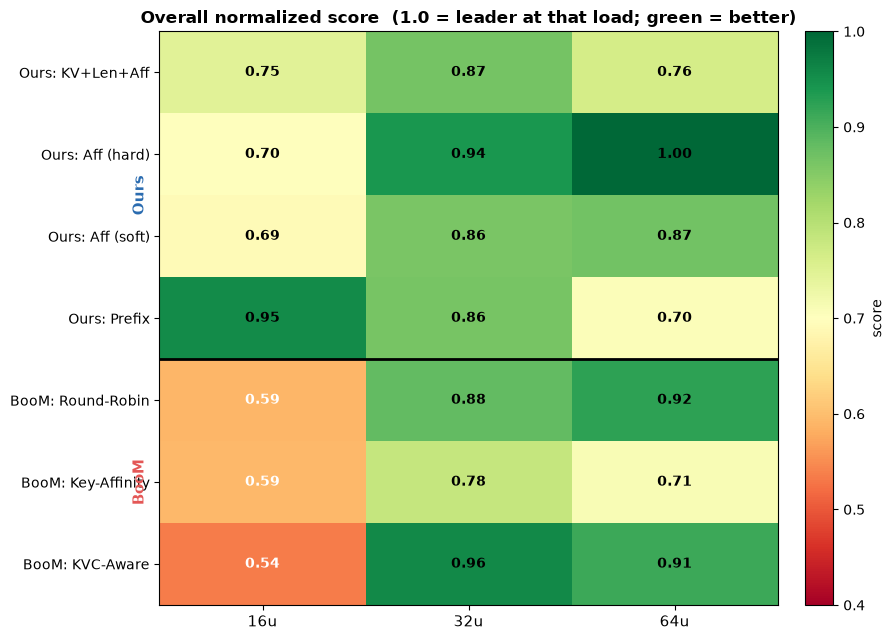

In [5]:
P = pivot("score").reindex(STRATS)
M = P.values.astype(float)
cmap = plt.cm.RdYlGn.copy(); cmap.set_bad("lightgray")
fig, ax = plt.subplots(figsize=(9, 6.5))
im = ax.imshow(np.ma.masked_invalid(M), cmap=cmap, vmin=0.4, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(USERS))); ax.set_xticklabels([f"{u}u" for u in USERS], fontsize=11)
ax.set_yticks(range(len(STRATS))); ax.set_yticklabels([PRETTY[s] for s in STRATS], fontsize=10)
for i in range(len(STRATS)):
    for j in range(len(USERS)):
        v = M[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10,
                    color=("black" if v > 0.6 else "white"), fontweight="bold")
        else:
            ax.text(j, i, "n/a", ha="center", va="center", fontsize=8, color="gray")
# separate Ours block from BooM block
ax.axhline(len(MINE_STRATS) - 0.5, color="black", lw=2)
ax.set_title("Overall normalized score  (1.0 = leader at that load; green = better)",
             fontsize=12, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("score")
ax.text(-0.02, (len(MINE_STRATS)-1)/2, "Ours", transform=ax.get_yaxis_transform(),
        rotation=90, va="center", ha="right", fontsize=11, fontweight="bold", color=OURS_BLUE)
ax.text(-0.02, len(MINE_STRATS)+(len(BOOM_STRATS)-1)/2, "BooM",
        transform=ax.get_yaxis_transform(), rotation=90, va="center", ha="right",
        fontsize=11, fontweight="bold", color=BOOM_RED)
plt.tight_layout(); plt.show()


## 5. Selected results from the per-level deep-dive notebooks

For reference, the headline numbers **as reported by the per-level notebooks**
(`u16/u32/u64-mine-vs-boom.ipynb`). Those notebooks compute the overall score over the same
5 metrics but source E2E/TPS slightly differently (u16/u32 use Prometheus; u64 uses workload
logs), so their single-level headline % differ a little from the uniform recompute above — both
are shown so the story is fully traceable. Per-metric % = best-Ours improvement over best-BooM.

Per-level deep-dive headlines (best-Ours vs best-BooM; + = Ours better)


,best Ours,best BooM,overall %,TTFT %,TPOT %,E2E %,RPS %,TPS %
users,,,,,,,,
16,Ours: Prefix,BooM: Round-Robin,53,9,11,28,318,82
32,Ours: Aff (hard),BooM: KVC-Aware,1,1,3,1,-4,15
64,Ours: Aff (hard),BooM: Round-Robin,8,NaN,NaN,19,5,2


note: u64 TTFT/TPOT = n/a (engine metrics past Prometheus retention for 139-144).
note: 128u level excluded from this cross-load view (saturation; see u128 notebook).


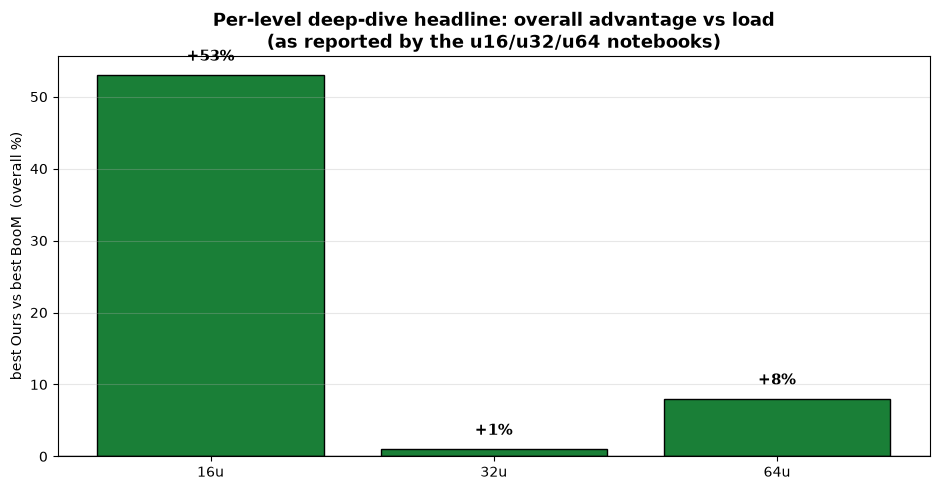

In [6]:
# static headlines copied from the executed per-level notebooks (Section 8/9 outputs)
DEEP = {
    16:  dict(best_ours="Ours: Prefix",    best_boom="BooM: Round-Robin", gap=+53,
              ttft=+9,  tpot=+11, e2e=+28, rps=+318, tps=+82),
    32:  dict(best_ours="Ours: Aff (hard)", best_boom="BooM: KVC-Aware",   gap=+1,
              ttft=+1,  tpot=+3,  e2e=+1,  rps=-4,   tps=+15),
    64:  dict(best_ours="Ours: Aff (hard)", best_boom="BooM: Round-Robin", gap=+8,
              ttft=np.nan, tpot=np.nan, e2e=+19, rps=+5, tps=+2),   # TTFT/TPOT past retention
}
tbl = pd.DataFrame(DEEP).T
tbl.index.name = "users"
tbl = tbl[["best_ours", "best_boom", "gap", "ttft", "tpot", "e2e", "rps", "tps"]]
tbl.columns = ["best Ours", "best BooM", "overall %", "TTFT %", "TPOT %",
               "E2E %", "RPS %", "TPS %"]
print("Per-level deep-dive headlines (best-Ours vs best-BooM; + = Ours better)")
display(tbl)
print("note: u64 TTFT/TPOT = n/a (engine metrics past Prometheus retention for 139-144).")
print("note: 128u level excluded from this cross-load view (saturation; see u128 notebook).")

# bar: per-level overall gap as reported by the deep-dive notebooks
fig, ax = plt.subplots(figsize=(9.5, 5))
gaps = [DEEP[u]["gap"] for u in USERS]
cols = ["#1a7f37" if g >= 0 else "#b4413c" for g in gaps]
ax.bar([f"{u}u" for u in USERS], gaps, color=cols, edgecolor="black")
ax.axhline(0, color="black", lw=1)
for i, g in enumerate(gaps):
    ax.text(i, g + (1.5 if g >= 0 else -1.5), f"{g:+d}%", ha="center",
            va=("bottom" if g >= 0 else "top"), fontsize=11, fontweight="bold")
ax.set_ylabel("best Ours vs best BooM  (overall %)")
ax.set_title("Per-level deep-dive headline: overall advantage vs load\n"
             "(as reported by the u16/u32/u64 notebooks)",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()
